# Análise de Processamento Paralelo - OpenMP

**Universidade Estadual de Santa Cruz - UESC**

**Discente:** Everaldina Guimarães Barbosa

**Docente:** Prof. Dr. Esbel Tomas Valero Orellana

**Disciplina:** Processamento Paralelo


## 1. Introdução

Este relatório teve como objetivo analisar o desempenho computacional de um programa desenvolvido em C++, estruturado em duas abordagens: uma sequencial e outra paralela, atravez da biblioteca OpenMP. O sistema consistiu na verificação da similaridade entre pares de tomografias computadorizadas (A e B) tridimensionais, com dimensões representadas por (X, Y, Z). A metodologia do algoritmo baseou-se em extrair o corte central do eixo Z da tomografia A e compará-lo com todos os cortes ao longo do eixo Z da tomografia B. Para quantificar essa correspondência, adotou-se a métrica do Índice de Similaridade Estrutural (SSIM). Ao final da varredura, a aplicação retornava o valor máximo de similaridade detectado, juntamente com o índice numérico do corte da tomografia B correspondente.

Todo o código-fonte, englobando a implementação em C++, os *scripts* de teste, cadernos de anotação (*notebooks*) e os resultados obtidos, encontra-se publicamente disponível no repositório do projeto: [processamento-paralelo](https://github.com/everaldina/processamento-paralelo).

## 2. Metodologia

### 2.1 Conjunto de dados

Os experimentos foram conduzidos utilizando o conjunto de dados *OrcaScore*, que dispõe de 72 pares de tomografias computadorizadas cardíacas. Cada par é constituído por uma imagem capturada com injeção de contraste e outra sem contraste, ambas possuindo dimensões de (512, 512, Z). A profundidade Z varia: entre 167 e 640 cortes para as imagens com contraste, e entre 36 e 64 cortes para as imagens sem contraste.

A base é originalmente dividida em três subconjuntos: treino (32 pares), teste (32 pares) e validação (8 pares), cujas aquisições vinham de quatro tomógrafos distintos, designados como V1, V2, V3 e V4. Visando otimizar o tempo de processamento e viabilizar a execução de todos os cenários de teste, os exames originários do equipamento V2 foram restritos apenas ao conjunto de validação, reduzindo a amostra total analisada para 56 pares. Essa restrição foi adotada porque as tomografias com contraste do equipamento V2 apresentavam um volume de cortes superior (mínimo de 480 cortes) em comparação aos demais (máximo de 380 cortes), o que elevaria o custo computacional a níveis que inviabilizariam os prazos do projeto.


### 2.2 Implementação do Índice de Similaridade Estrutural (SSIM)

A lógica de cálculo do SSIM foi fundamentada na implementação da biblioteca *scikit-image*, nativa da linguagem Python, especificamente no módulo [structural_similarity](https://github.com/scikit-image/scikit-image/blob/main/src/_skimage2/metrics/_structural_similarity.py). O código Python de referência foi preservado no momento da implementação em C++ no arquivo [function_base.py](ref_codes/function_base.py) presente no repositório do projeto.

Foi realizada uma tradução direta do código em Python para C++, visando assegurar a mesma fidelidade matemática no programa principal. Essa implementação pode ser encontrada no arquivo [ssim_impl.hpp](src\metrics\ssim_impl.hpp).

### 2.3 Resumo da Implementação

A rotina principal do sistema incorpora um controle de repetições (número de iterações por teste) para extrair uma média confiável do tempo de execução da comparação, mitigando o impacto de flutuações e ruídos do sistema operacional durante as medições.

O programa itera sobre uma lista predefinida de identificadores de exames. Para cada par, realizava-se uma dupla verificação para avaliar o impacto da volumetria de cortes no tempo computacional:
1. Tomografia A (sem contraste) comparada à Tomografia B (com contraste).
2. Invertendo a ordem: Tomografia A (com contraste) comparada à Tomografia B (sem contraste).

Adicionalmente, os cálculos foram executados iterando-se sobre diferentes tamanhos de janela de convolução (parâmetro `window_size` ou *kernel*), essencial para o filtro do SSIM. Na versão sequencial, os *kernels* também foram iterados ao longo da execução.

Em pseudocódigo, a estrutura do programa sequencial era a seguinte:

```python
para id em lista_de_ids:
    caminho_imagem_A = id + "_sem_contraste"
    caminho_imagem_B = id + "_com_contraste"

    para kernel em lista_de_kernels:
        para repeticao em numero_de_repeticoes:
            resultado = comparar_imagens(caminho_imagem_A, caminho_imagem_B, kernel)

    caminho_imagem_A = id + "_com_contraste"
    caminho_imagem_B = id + "_sem_contraste"

    para kernel em lista_de_kernels:
        para repeticao em numero_de_repeticoes:
            resultado = comparar_imagens(caminho_imagem_A, caminho_imagem_B, kernel)
```

Para a implementação paralela, os *kernels* e o número de *threads* foram passados como parâmetros para o programa, além de uma variável para definir o `batch_size` do laço que iterava sobre as fatias da imagem. A estrutura do programa ficou definida da seguinte forma:

```python
para id em lista_de_ids:
    caminho_imagem_A = id + "_sem_contraste"
    caminho_imagem_B = id + "_com_contraste"

    para repeticao em numero_de_repeticoes:
        resultado = comparar_imagens(caminho_imagem_A, caminho_imagem_B, kernel, numero_de_threads, batch_size)

    caminho_imagem_A = id + "_com_contraste"
    caminho_imagem_B = id + "_sem_contraste"

    para repeticao em numero_de_repeticoes:
        resultado = comparar_imagens(caminho_imagem_A, caminho_imagem_B, kernel, numero_de_threads, batch_size)
```

A função `comparar_imagens` realiza a leitura dos dados utilizando uma implementação disponível em [mhd_reader.hpp](src\utils\mhd_reader.hpp), que dispõe de diversas funções para manipular imagens tomográficas. Todas utilizavam alocação dinâmica, garantindo que a matriz fosse armazenada em um bloco contínuo de memória, o que favoreceu a paralelização.

Após a leitura, o corte central da dimensão Z da imagem A era selecionado e comparado com todos os cortes da dimensão Z da imagem B utilizando a função de SSIM. O rastreamento temporal foi implementado via biblioteca `<chrono>` da linguagem C++. Foram medidos três fases distintas de tempo: tempo de leitura (I/O das imagens), tempo de busca (laço iterativo do cálculo de SSIM) e tempo total da execução. Adicionalmente, antes e depois de calcular o SSIM entre os cortes, o programa registrava o tempo gasto para calcular a média computacional de cada *slice* nos logs de saída.

Em pseudocódigo, a estrutura da função `comparar_imagens` sequencial era a seguinte:

```python
inicio_comparacao = tempo_atual()
inicio_leitura = tempo_atual()
imagem_A = ler_imagem(caminho_imagem_A)
imagem_B = ler_imagem(caminho_imagem_B)
fim_leitura = tempo_atual()
tempo_leitura = fim_leitura - inicio_leitura

corte_central_A = selecionar_corte_central(imagem_A)

maior_similaridade = -1
numero_do_corte_B = -1

inicio_busca = tempo_atual()
para corte_B em cortes_da_imagem_B:
    tempo_slice = tempo_atual()
    ssim = calcular_ssim(corte_central_A, corte_B, kernel)
    tempo_slice = tempo_atual() - tempo_slice
    se ssim > maior_similaridade:
        maior_similaridade = ssim
        numero_do_corte_B = corte_B
fim_busca = tempo_atual()

tempo_busca = fim_busca - inicio_busca

fim_comparacao = tempo_atual()
tempo_avg_slice = tempo_busca / numero_de_cortes_B
tempo_total = fim_comparacao - inicio_comparacao
```

Para a versão paralela, definiu-se uma região paralela prévia ao laço de busca, alocando variáveis privadas locais para o acompanhamento do maior SSIM e do respectivo índice em cada *thread*. A distribuição de carga sobre o laço iterativo dos cortes de B foi feita pela diretiva `#pragma omp parallel for`. Ao término da execução local, utilizou-se a diretiva `#pragma omp critical` para garantir que apenas uma *thread* por vez atualizasse os valores globais, evitando condições de corrida.

Em pseudocódigo, a versão paralela de `comparar_imagens` configurou-se da seguinte maneira:

```python
inicio_comparacao = tempo_atual()
inicio_leitura = tempo_atual()
imagem_A = ler_imagem(caminho_imagem_A)
imagem_B = ler_imagem(caminho_imagem_B)
fim_leitura = tempo_atual()
tempo_leitura = fim_leitura - inicio_leitura

corte_central_A = selecionar_corte_central(imagem_A)

maior_similaridade = -1
numero_do_corte_B = -1

inicio_busca = tempo_atual()
aberta_regiao_paralela:
    maior_similaridade_local = -1
    numero_do_corte_B_local = -1

    pragma omp for nowait schedule(<schedule>, batch_size)
    para corte_B em cortes_da_imagem_B:
        tempo_slice = tempo_atual()
        ssim = calcular_ssim(corte_central_A, corte_B, kernel)
        tempo_slice = tempo_atual() - tempo_slice
        se ssim > maior_similaridade_local:
            maior_similaridade_local = ssim
            numero_do_corte_B_local = corte_B

    #pragma omp critical
    se maior_similaridade_local > maior_similaridade:
        maior_similaridade = maior_similaridade_local
        numero_do_corte_B = numero_do_corte_B_local
fim_busca = tempo_atual()

tempo_busca = fim_busca - inicio_busca

fim_comparacao = tempo_atual()
tempo_avg_slice = tempo_busca / numero_de_cortes_B
tempo_total = fim_comparacao - inicio_comparacao
```

Todo o processamento gerava saídas formatadas em logs de texto, onde foram registrados os IDs das imagens, o *kernel*, o número de *threads*, o `batch_size` e os tempos obtidos. O tempo de escrita nos arquivos foi isolado propositalmente para não impactar e poluir as métricas de comparação de desempenho do sistema.

### 2.4 Testes Realizados

A execução da versão sequencial englobou os 72 pares de imagens originais, testados sob os *kernels* 3, 5, 7 e 9. Cada combinação de imagem e *kernel* foi executada 10 vezes com a alternância das imagens A e B, resultando em 5.760 testes globais.

Em seguida, procedeu-se a um teste de corretude, comparando diretamente as saídas computadas em C++ com uma replica implementada em Python.

Para a abordagem paralela, limitou-se o escopo aos *kernels* 5, 7 e 9 e a 5 repetições por par, excluindo-se as imagens do equipamento V2. Foram testadas duas estratégias do OpenMP: `static` e `dynamic`. 

Também foram realizados levantamentos para analisar a influência do tamanho de lote, variando o `batch_size` entre 2, 4, 8, 16, 32 e 64, além do cenário de omissão (representado nos resultados numéricos por `batch_size` 0). Para cada arranjo, empregaram-se 2, 4 e 8 *threads*, totalizando 11.760 testes. As métricas comparativas utilizaram apenas o correspondente recorte de dados sequenciais.

Após a realização dos testes paralelos, todos os resultados voltaram a ser cruzados com a matriz sequencial inicial para assegurar a integridade total do processamento de paralelização.

### 2.5 Hardware e Software Utilizado

A execução de todos os testes ocorreu em uma máquina equipada com processador Intel Core i5-1135G7 @ 2.40GHz (4 núcleos físicos, 8 núcleos lógicos) e 8 GB de memória RAM, executando o sistema operacional Windows 11. O compilador adotado foi o `g++` (via MinGW), acionado com as diretivas `-fopenmp` para suporte ao processamento paralelo e `-O3` para o nível máximo de otimização de código.

## 3. Resultados

- Preparação do ambiente

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
NUCLEOS_FISICOS = 4
NUCLEOS_LOGICOS = 8

In [3]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

### 3.1 Abordagem sequencial

- Leitura de dados

In [4]:
def read_log(path: str) -> str:
    """Lê o conteúdo do arquivo de log e retorna como string."""
    with open(path, 'r') as f:
        log_content = f.read()
    return log_content

In [5]:
def parse_log(log_data: str) -> pd.DataFrame:
    """Converte o conteúdo do log estruturado em um DataFrame do pandas."""
    records = []
    current_record = {}

    for line in log_data.strip().split('\n'):
        line = line.strip()
        if line.startswith('ID da Imagem:'):
            current_record['id'] = line.split(': ')[1]
        elif line.startswith('Quantidade de cortes B avaliados:'):
            current_record['cortes'] = int(line.split(': ')[1])
        elif line.startswith('Kernel Window Size:'):
            current_record['windows_size'] = line.split(': ')[1]
        elif line.startswith('Tempo de Leitura Total (A+B):'):
            current_record['tempo_leitura'] = float(line.split(': ')[1].replace(' s', ''))
        elif line.startswith('Tempo Medio Calculo SSIM (por slice):'):
            current_record['tempo_medio_slice'] = float(line.split(': ')[1].replace(' s', ''))
        elif line.startswith('Tempo de Busca (SSIM loop):'):
            current_record['tempo_busca'] = float(line.split(': ')[1].replace(' s', ''))
        elif line.startswith('Tempo Total do Processo:'):
            current_record['tempo_total'] = float(line.split(': ')[1].replace(' s', ''))
        elif line.startswith('Melhor Slice (Z):'):
            current_record['melhor_corte'] = int(line.split(': ')[1])
        elif line.startswith('SSIM Maximo Encontrado:'):
            current_record['ssim_maximo'] = float(line.split(': ')[1])
            records.append(current_record)
            current_record = {}
    return pd.DataFrame(records)

In [6]:
file_path = "output\sequencial.txt"
if os.path.exists(file_path):
    with open(file_path, 'r') as f:
        log_content = f.read()
    sequencial = parse_log(log_content)
    df_seq = pd.DataFrame(sequencial)
else:
    print(f"Arquivo {file_path} não encontrado.")

In [7]:
df_seq['batch_size'] = None
df_seq['threads'] = None
df_seq['schedule'] = 'sequencial'
df_seq.head()

,id,windows_size,cortes,tempo_leitura,tempo_medio_slice,tempo_busca,tempo_total,melhor_corte,ssim_maximo,batch_size,threads,schedule
0,TRV1P1,3,280,0.782536,0.005276,1.478240,2.261822,198,0.866923,None,None,sequencial
1,TRV1P1,3,280,0.786043,0.005591,1.566349,2.353509,198,0.866923,None,None,sequencial
2,TRV1P1,3,280,0.809144,0.005181,1.450965,2.261208,198,0.866923,None,None,sequencial
3,TRV1P1,3,280,0.855297,0.005111,1.431570,2.288085,198,0.866923,None,None,sequencial
4,TRV1P1,3,280,0.754657,0.005682,1.591265,2.347004,198,0.866923,None,None,sequencial


In [8]:
df_seq.columns

Index(['id', 'windows_size', 'cortes', 'tempo_leitura', 'tempo_medio_slice',
       'tempo_busca', 'tempo_total', 'melhor_corte', 'ssim_maximo',
       'batch_size', 'threads', 'schedule'],
      dtype='str')

#### Análise de Desempenho

A bateria de testes sequenciais contabilizou 5.760 execuções. O tempo médio gasto para a comparação completa e isolada de um par de tomografias foi de aproximadamente 4,27 segundos. Essa métrica se divide essencialmente em etapas de leitura (média de 0,94s) e busca computacional do melhor corte (média de 3,32s).

In [9]:
df_seq[["cortes", "tempo_leitura", "tempo_medio_slice", 
    "tempo_busca", "tempo_total"]].describe()

,cortes,tempo_leitura,tempo_medio_slice,tempo_busca,tempo_total
count,5760.000000,5760.000000,5760.000000,5760.000000,5760.000000
mean,191.034722,0.942780,0.017371,3.323824,4.267557
std,164.288779,0.282420,0.009596,3.739000,3.839745
min,36.000000,0.452191,0.004818,0.187874,0.705875
25%,47.000000,0.711549,0.009978,0.806965,1.678811
50%,115.500000,0.894964,0.016973,1.508314,2.502263
75%,296.250000,1.155213,0.025019,5.186009,5.904651
max,640.000000,2.831564,0.035460,19.995227,21.696141


In [10]:
df_seq['windows_size'].unique()

<StringArray>
['3', '5', '7', '9']
Length: 4, dtype: str

Analisando a distribuição desses tempos por meio do *boxplot* gerado, evidenciou-se que o gasto com leitura possuía baixa variância e magnitude. Em contrapartida, a curva do tempo de busca acompanhou o tempo total, indicando que o laço de cálculo do SSIM consistia no grande gargalo do fluxo principal.

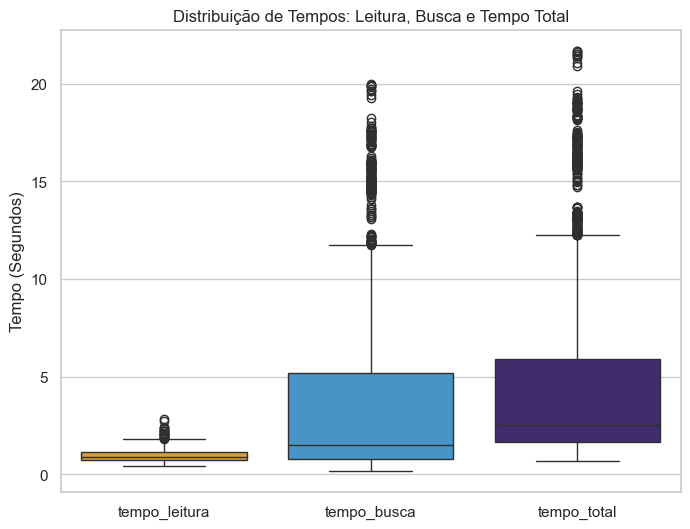

In [11]:
plt.figure(figsize=(8, 6))

df_melted = df_seq[['tempo_leitura', 'tempo_busca', 'tempo_total']].melt(
    var_name='Etapa do Processamento', 
    value_name='Tempo (s)'
)

sns.boxplot(
    data=df_melted,
    x='Etapa do Processamento',
    y='Tempo (s)',
    palette=["#f3a322", '#3498db', "#3D2279"],
    hue='Etapa do Processamento',
)

plt.title('Distribuição de Tempos: Leitura, Busca e Tempo Total')
plt.ylabel('Tempo (Segundos)')
plt.xlabel('')
plt.show()

Com os dados extraídos, foi possível constatar o impacto da quantidade de cortes e do tamanho da janela (*kernel*) no custo temporal. O número de cortes tem comportamento basicamente linear. Além disso, o *kernel* teve influência importante, convoluções de matrizes menores efetuam substancialmente menos operações aritméticas, gerando um processo mais rápido. Logo, qualquer ponderação de velocidade futura precisa, impreterivelmente, alinhar estas duas características como agregador, visto que elas têm um impacto significativo no tempo gasto para a execução do programa.

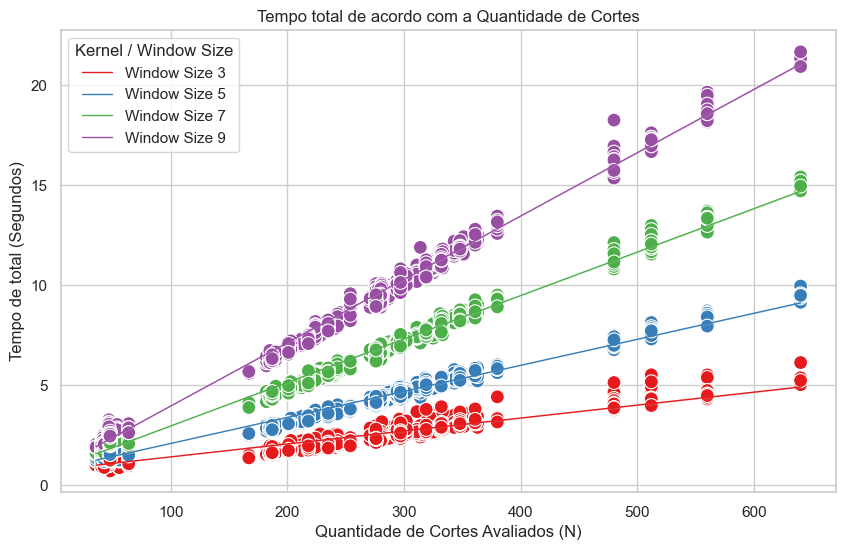

In [12]:
plt.figure(figsize=(10, 6))

windows_sizes = df_seq['windows_size'].unique()
colors = sns.color_palette('Set1', n_colors=len(windows_sizes))
color_map = {ws: colors[i] for i, ws in enumerate(windows_sizes)}


sns.scatterplot(
    data=df_seq, 
    x='cortes', 
    y='tempo_total', 
    s=100,
    palette=color_map,
    hue='windows_size',
    legend=False
)

for ws in windows_sizes:
    subset = df_seq[df_seq['windows_size'] == ws]
    sns.regplot(
        data=subset,
        x='cortes',
        y='tempo_total',
        scatter=False,
        color=color_map[ws],
        line_kws={'linewidth': 1},
        label=f'Window Size {ws}'
    )
plt.legend(title='Kernel / Window Size')
plt.title('Tempo total de acordo com a Quantidade de Cortes')
plt.ylabel('Tempo de total (Segundos)')
plt.xlabel('Quantidade de Cortes Avaliados (N)')
plt.show()

Antes de definir a abordagem na utilização do OpenMP, avaliou-se o tempo exigido para calcular apenas a métrica de um par de fatias. 

Esse montante oscilou de maneira minima e com valores de magnitude pouco significativa (entre 0,0048s e 0,0354s). Avaliações do Coeficiente de Variação (CV) indicaram variabilidade mínima no escopo de *kernels* (CV $\le$ 0,0577), logo todos os diferentes cenários de teste apresentaram tempos de cálculo de SSIM com baixa dispersão e magnitude reduzida.

Diante de tamanha rapidez, ficou evidente que paralelizar a nível do cálculo do SSIM não traria benefícios reais, visto que o tempo gasto para gerenciar as *threads* e dividir as tarefas seria maior do que o ganho de desempenho obtido com a divisão do trabalho. Em virtude disto, as diretivas do compilador atuaram exclusivamente no laço externo de distribuição das imagens.

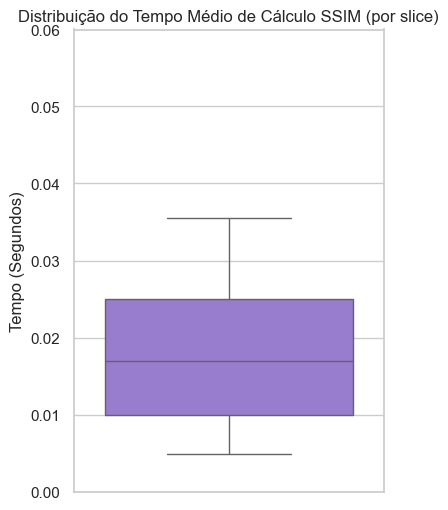

In [13]:
plt.figure(figsize=(4, 6))
sns.boxplot(
    data=df_seq,
    y='tempo_medio_slice', 
    color='mediumpurple'
)

plt.title('Distribuição do Tempo Médio de Cálculo SSIM (por slice)')
plt.ylabel('Tempo (Segundos)')
plt.xlabel('')
plt.ylim(0.00, 0.06)
plt.show()

In [14]:
df_grouped_tempo_medio = df_seq[['tempo_medio_slice', 'windows_size']].groupby(['windows_size'])
df_grouped_tempo_medio = df_grouped_tempo_medio['tempo_medio_slice'].agg(['mean', 'median', 'std', 'min', 'max'])
df_grouped_tempo_medio.reset_index(inplace=True)
df_grouped_tempo_medio['CV'] = (df_grouped_tempo_medio['std'] / df_grouped_tempo_medio['mean'])
df_grouped_tempo_medio.sort_values(by='median')

,windows_size,mean,median,std,min,max,CV
0,3,0.005414,0.005343,0.000312,0.004818,0.006648,0.057713
1,5,0.012200,0.012089,0.000567,0.011088,0.014806,0.046498
2,7,0.020973,0.020791,0.000896,0.019141,0.023940,0.042729
3,9,0.030899,0.030756,0.001156,0.028255,0.035460,0.037414


#### Teste de corretude

Para verificar a integridade matemática da implementação em C++, as saídas foram contrapostas a um *script* gêmeo escrito e testado em Python (com embasamento na *scikit-image*), utlizado como referencial de corretude.

In [15]:
file_path = "output\log_python.txt"
if os.path.exists(file_path):
    with open(file_path, 'r') as f:
        log_content = f.read()
    python_result = parse_log(log_content)
    df_python = pd.DataFrame(python_result)
else:
    print(f"Arquivo {file_path} não encontrado.")

In [16]:
df_python['batch_size'] = None
df_python['threads'] = None
df_python['schedule'] = 'python'
df_python.head()

,id,windows_size,cortes,tempo_leitura,tempo_medio_slice,tempo_busca,tempo_total,melhor_corte,ssim_maximo,batch_size,threads,schedule
0,TRV1P1,3,280,1.768179,0.044250,12.394200,14.162380,198,0.866826,None,None,python
1,TRV1P1,5,280,0.552315,0.039298,11.004322,11.557642,198,0.868309,None,None,python
2,TRV1P1,7,280,0.534709,0.047827,13.395577,13.930286,198,0.869912,None,None,python
3,TRV1P1,9,280,0.690767,0.043644,12.224909,12.916679,198,0.871462,None,None,python
4,TRV1P1,3,64,0.564850,0.035101,2.247443,2.813299,27,0.857731,None,None,python


In [17]:
df_python['windows_size'].unique()

<StringArray>
['3', '5', '7', '9']
Length: 4, dtype: str

Por se tratar de linguagens distintas que tratam a precisão do ponto flutuante de formas diferentes na memória, fixou-se uma tolerância de checagem para o SSIM em 1e-3.

In [18]:
tolerancia_teste = 1e-3

In [19]:
def teste_corretude(df_ref: pd.DataFrame, df_comp: pd.DataFrame, lista_ids: list,
                    nome_ref: str, nome_comp: str,
                    tolerance_ssim: float = 1e-25) -> dict:
    """" 
    Compara os resultados de dois DataFrames para verificar a corretude dos resultados. 
    São comparados o melhor corte encontrado e o valor máximo de SSIM para cada combinação de ID, e número de cortes.
    
    Args:
        df_ref (pd.DataFrame): DataFrame de referência a ser comparado.
        df_comp (pd.DataFrame): DataFrame a ser comparado com o de referência.
        ids (list): Lista de IDs a serem verificados.
        nome_ref (str): Nome do DataFrame de referência para logs.
        nome_comp (str): Nome do DataFrame de comparação para logs.
        tolerance_ssim (float, optional): Tolerância para comparação de valores de SSIM. Defaults to 1e-25.
    Returns:
        dict: Dicionário contendo o número total de comparações realizadas (num_comp), 
        o número de diferenças encontradas nos valores de SSIM (num_ssim_diff) e 
        o número de diferenças encontradas nos melhores cortes (num_index_diff).
    """

    num_comp = 0
    num_index_diff = 0
    num_ssim_diff = 0

    for i, id in enumerate(lista_ids):
        imprimir = (i < 2) or (i >= len(lista_ids) - 2)  # Imprime os primeiros e últimos 5 IDs para verificação
        
        df_select_ref = df_ref[df_ref['id'] == id]
        df_select_comp = df_comp[df_comp['id'] == id]
        if df_select_ref.empty or df_select_comp.empty:
            print(f"Falha: ID {id} não encontrado em um dos DataFrames. Verifique os dados de entrada.")
            continue
        
        # Dois valores de cortes, um com comparaçao de tomografia com contraste como referencia, 
        # e outro sem contraste como referencia, entao é esperado que haja 2 cortes diferentes para cada ID
        cortes = set(list(df_select_ref['cortes'].unique()) + list(df_select_comp['cortes'].unique()))
        if len(cortes) != 2:
            print(f"Alerta: Número inesperado de cortes para ID {id}. Encontrados cortes: {cortes}")

        for corte in cortes:
            df_corte_ref = df_select_ref[df_select_ref['cortes'] == corte]
            df_corte_comp = df_select_comp[df_select_comp['cortes'] == corte]
            
            if df_corte_ref.empty or df_corte_comp.empty:
                print(f"ID {id} | Cortes {corte}: Faltando em um dos DataFrames (ignorando corte).")
                continue
            
            num_comp += 1
            
            #### COMPARAÇÃO DE MELHOR CORTE ENTRE PARALÉLO E SEQUENCIAL ####
            index_set_ref = set(df_corte_ref['melhor_corte'])
            index_set_comp = set(df_corte_comp['melhor_corte'])
            
            indice_correto = (index_set_ref == index_set_comp)
            if not indice_correto:
                num_index_diff += 1
            
            # Logs de warninga para resultados incosistentes
            if len(index_set_ref) > 1:
                print(f"Variação nos indices '{nome_ref}' | ID {id} | Cortes {corte} | Valores: {index_set_ref}")
            if len(index_set_comp) > 1:
                print(f"Variação nos indices '{nome_comp}' | ID {id} | Cortes {corte} | Valores: {index_set_comp}")

            
            #### COMPARAÇÃO DE VALORES DE SSIM MÁXIMO ENTRE PARALÉLO E SEQUENCIAL ####
            set_max_ssim_ref = set(df_corte_ref['ssim_maximo'])
            set_max_ssim_comp = set(df_corte_comp['ssim_maximo'])

            # Logs de warninga para resultados incosistentes
            if len(set_max_ssim_ref) > 1:
                print(f"Variação nos valores de SSIM '{nome_ref}' | ID {id} | Cortes {corte} | Valores: {set_max_ssim_ref}")
            if len(set_max_ssim_comp) > 1:
                print(f"Variação nos valores de SSIM '{nome_comp}' | ID {id} | Cortes {corte} | Valores: {set_max_ssim_comp}")
            
            ssim_correto = True
            if abs(next(iter(set_max_ssim_ref)) - next(iter(set_max_ssim_comp))) > tolerance_ssim:
                ssim_correto = False
                num_ssim_diff += 1
                
            if imprimir or not indice_correto or not ssim_correto:
                print(f"ID {id} | Cortes {corte}")
                
                if not indice_correto:
                    print(f"  - Índice: {nome_ref} {index_set_ref} != {nome_comp} {index_set_comp}")
                if not ssim_correto:
                    print(f"  - SSIM: {nome_ref} {set_max_ssim_ref} != {nome_comp} {set_max_ssim_comp}")
                    
                if indice_correto and ssim_correto:
                    print(f"  - Resultados consistentes")

    return {
        'num_comp': num_comp,
        'num_index_diff': num_index_diff,
        'num_ssim_diff': num_ssim_diff
    }

As avaliações de índice realizadas com os *kernels* 3 e 9 tiveram resultados perfeito, nenhuma anomalia de corte encontrado ou falha numérica de cálculo de SSIM. Apenas para a matriz de escopo 5 e 7 observou-se, que um exame divergiu na escolha do melhor índice. Ainda assim, a diferença flutuante da pontuação desse teste manteve-se inferior ao limiar de 1e-3 da variação estipulada. O que indica que os resultados estavam próximos e isso pode ter sido causado por de tratamento de tipo entre linguagens. Logo, a viabilidade lógica e estrutural do modelo de C++ foi considerada valida.

In [20]:
result = teste_corretude(df_ref = df_python[df_python['windows_size'] == '3'],
                         df_comp = df_seq[df_seq['windows_size'] == '3'],
                         lista_ids = df_python['id'].unique(), 
                         nome_ref = 'Python',
                         nome_comp = 'Sequencial',
                         tolerance_ssim=tolerancia_teste)
print(f"Total de comparações: {result['num_comp']}")
print(f"Diferenças encontradas nos melhores cortes: {result['num_index_diff']}")
print(f"Diferenças encontradas nos valores de SSIM: {result['num_ssim_diff']}")

ID TRV1P1 | Cortes 280
  - Resultados consistentes
ID TRV1P1 | Cortes 64
  - Resultados consistentes
ID TRV1P2 | Cortes 56
  - Resultados consistentes
ID TRV1P2 | Cortes 182
  - Resultados consistentes
ID VAV4P1 | Cortes 48
  - Resultados consistentes
ID VAV4P1 | Cortes 348
  - Resultados consistentes
ID VAV4P2 | Cortes 48
  - Resultados consistentes
ID VAV4P2 | Cortes 332
  - Resultados consistentes
Total de comparações: 144
Diferenças encontradas nos melhores cortes: 0
Diferenças encontradas nos valores de SSIM: 0


In [21]:
result = teste_corretude(df_ref = df_python[df_python['windows_size'] == '5'],
                         df_comp = df_seq[df_seq['windows_size'] == '5'], 
                         lista_ids = df_python['id'].unique(), 
                         nome_ref = 'Python', 
                         nome_comp = 'Sequencial',
                         tolerance_ssim=tolerancia_teste)
print(f"Total de comparações: {result['num_comp']}")
print(f"Diferenças encontradas nos melhores cortes: {result['num_index_diff']}")
print(f"Diferenças encontradas nos valores de SSIM: {result['num_ssim_diff']}")

ID TRV1P1 | Cortes 280
  - Resultados consistentes
ID TRV1P1 | Cortes 64
  - Resultados consistentes
ID TRV1P2 | Cortes 56
  - Resultados consistentes
ID TRV1P2 | Cortes 182
  - Resultados consistentes
ID TRV1P3 | Cortes 56
  - Índice: Python {12} != Sequencial {22}
ID VAV4P1 | Cortes 48
  - Resultados consistentes
ID VAV4P1 | Cortes 348
  - Resultados consistentes
ID VAV4P2 | Cortes 48
  - Resultados consistentes
ID VAV4P2 | Cortes 332
  - Resultados consistentes
Total de comparações: 144
Diferenças encontradas nos melhores cortes: 1
Diferenças encontradas nos valores de SSIM: 0


In [22]:
result = teste_corretude(df_ref = df_python[df_python['windows_size'] == '7'],
                         df_comp = df_seq[df_seq['windows_size'] == '7'], 
                         lista_ids = df_python['id'].unique(), 
                         nome_ref = 'Python', 
                         nome_comp = 'Sequencial',
                         tolerance_ssim=tolerancia_teste)
print(f"Total de comparações: {result['num_comp']}")
print(f"Diferenças encontradas nos melhores cortes: {result['num_index_diff']}")
print(f"Diferenças encontradas nos valores de SSIM: {result['num_ssim_diff']}")

ID TRV1P1 | Cortes 280
  - Resultados consistentes
ID TRV1P1 | Cortes 64
  - Resultados consistentes
ID TRV1P2 | Cortes 56
  - Resultados consistentes
ID TRV1P2 | Cortes 182
  - Resultados consistentes
ID TEV4P2 | Cortes 311
  - Índice: Python {160} != Sequencial {161}
ID VAV4P1 | Cortes 48
  - Resultados consistentes
ID VAV4P1 | Cortes 348
  - Resultados consistentes
ID VAV4P2 | Cortes 48
  - Resultados consistentes
ID VAV4P2 | Cortes 332
  - Resultados consistentes
Total de comparações: 144
Diferenças encontradas nos melhores cortes: 1
Diferenças encontradas nos valores de SSIM: 0


In [23]:
result = teste_corretude(df_ref = df_python[df_python['windows_size'] == '9'],
                         df_comp = df_seq[df_seq['windows_size'] == '9'], 
                         lista_ids = df_python['id'].unique(), 
                         nome_ref = 'Python', 
                         nome_comp = 'Sequencial',
                         tolerance_ssim=tolerancia_teste)
print(f"Total de comparações: {result['num_comp']}")
print(f"Diferenças encontradas nos melhores cortes: {result['num_index_diff']}")
print(f"Diferenças encontradas nos valores de SSIM: {result['num_ssim_diff']}")

ID TRV1P1 | Cortes 280
  - Resultados consistentes
ID TRV1P1 | Cortes 64
  - Resultados consistentes
ID TRV1P2 | Cortes 56
  - Resultados consistentes
ID TRV1P2 | Cortes 182
  - Resultados consistentes
ID VAV4P1 | Cortes 48
  - Resultados consistentes
ID VAV4P1 | Cortes 348
  - Resultados consistentes
ID VAV4P2 | Cortes 48
  - Resultados consistentes
ID VAV4P2 | Cortes 332
  - Resultados consistentes
Total de comparações: 144
Diferenças encontradas nos melhores cortes: 0
Diferenças encontradas nos valores de SSIM: 0


#### Filtragem de dados


Devido a limitações operacionais da máquina frente ao aumento do escopo dos testes de OpenMP, a matriz sequencial base precisou ser enxugada para garantir comparativos equitativos, desconsiderando *kernels* e amostras não presentes nas saídas paralelizadas.

In [24]:
df_seq = df_seq[df_seq['windows_size'].isin(['5', '7', '9'])]

In [25]:
unique_ids = df_seq['id'].unique()
print(unique_ids)
print(f"Total de IDs únicos iniciais: {len(unique_ids)}")

<StringArray>
['TRV1P1', 'TRV1P2', 'TRV1P3', 'TRV1P4', 'TRV1P5', 'TRV1P6', 'TRV1P7',
 'TRV1P8', 'TRV2P1', 'TRV2P2', 'TRV2P3', 'TRV2P4', 'TRV2P5', 'TRV2P6',
 'TRV2P7', 'TRV2P8', 'TRV3P1', 'TRV3P2', 'TRV3P3', 'TRV3P4', 'TRV3P5',
 'TRV3P6', 'TRV3P7', 'TRV3P8', 'TRV4P1', 'TRV4P2', 'TRV4P3', 'TRV4P4',
 'TRV4P5', 'TRV4P6', 'TRV4P7', 'TRV4P8', 'TEV1P1', 'TEV1P2', 'TEV1P3',
 'TEV1P4', 'TEV1P5', 'TEV1P6', 'TEV1P7', 'TEV1P8', 'TEV2P1', 'TEV2P2',
 'TEV2P3', 'TEV2P4', 'TEV2P5', 'TEV2P6', 'TEV2P7', 'TEV2P8', 'TEV3P1',
 'TEV3P2', 'TEV3P3', 'TEV3P4', 'TEV3P5', 'TEV3P6', 'TEV3P7', 'TEV3P8',
 'TEV4P1', 'TEV4P2', 'TEV4P3', 'TEV4P4', 'TEV4P5', 'TEV4P6', 'TEV4P7',
 'TEV4P8', 'VAV1P1', 'VAV1P2', 'VAV2P1', 'VAV2P2', 'VAV3P1', 'VAV3P2',
 'VAV4P1', 'VAV4P2']
Length: 72, dtype: str
Total de IDs únicos iniciais: 72


In [26]:
mask_val = df_seq['id'].str.contains('VA')
df_val = df_seq[mask_val]
df_non_val = df_seq[~mask_val]
df_non_val = df_non_val[~df_non_val['id'].str.contains('V2')]
df_seq_trimmed = pd.concat([df_val, df_non_val], ignore_index=True)

In [27]:
unique_ids = df_seq_trimmed['id'].unique()
print(unique_ids)
print(f"Total de IDs únicos finais: {len(unique_ids)}")

<StringArray>
['VAV1P1', 'VAV1P2', 'VAV2P1', 'VAV2P2', 'VAV3P1', 'VAV3P2', 'VAV4P1',
 'VAV4P2', 'TRV1P1', 'TRV1P2', 'TRV1P3', 'TRV1P4', 'TRV1P5', 'TRV1P6',
 'TRV1P7', 'TRV1P8', 'TRV3P1', 'TRV3P2', 'TRV3P3', 'TRV3P4', 'TRV3P5',
 'TRV3P6', 'TRV3P7', 'TRV3P8', 'TRV4P1', 'TRV4P2', 'TRV4P3', 'TRV4P4',
 'TRV4P5', 'TRV4P6', 'TRV4P7', 'TRV4P8', 'TEV1P1', 'TEV1P2', 'TEV1P3',
 'TEV1P4', 'TEV1P5', 'TEV1P6', 'TEV1P7', 'TEV1P8', 'TEV3P1', 'TEV3P2',
 'TEV3P3', 'TEV3P4', 'TEV3P5', 'TEV3P6', 'TEV3P7', 'TEV3P8', 'TEV4P1',
 'TEV4P2', 'TEV4P3', 'TEV4P4', 'TEV4P5', 'TEV4P6', 'TEV4P7', 'TEV4P8']
Length: 56, dtype: str
Total de IDs únicos finais: 56


### 3.2. Comparação de Schedules

Os testes compararam os paradigmas de distribuição de carga `static` e `dynamic`, alterando também a quantidade de núcleos designados e testando os parâmetros de `batch_size`. O objetivo direto dessa fase foi identificar com dados estatísticos o melhor formato de de distribuição de carga para o programa dentre os testes realizados.

- Leitura de dados

In [28]:
data_frames = []
OUTPUT_DIR = "output"
sizes = [0, 2, 4, 8, 16, 32, 64]
threads = [2, 4, 8]
kernels = [5, 7, 9]

In [29]:
### Metodo de schedule static ###
for size in sizes:
    for thread in threads:
        for kernel in kernels:
            filename = f"slices_static{size}_t{thread}_k{kernel}.txt"
            filepath = os.path.join(OUTPUT_DIR, filename)
            if os.path.exists(filepath):
                log_content = read_log(filepath)
                df = parse_log(log_content)
                data_frames.append(df)
                df['batch_size'] = size
                df['threads'] = thread
                df['schedule'] = 'static'
                data_frames.append(df)
            else:
                print(f"Arquivo {filename} não encontrado.")

In [30]:
### Metodo de schedule dynamic ###
for size in sizes:
    for thread in threads:
        for kernel in kernels:
            filename = f"slices_dynamic{size}_t{thread}_k{kernel}.txt"
            filepath = os.path.join(OUTPUT_DIR, filename)
            if os.path.exists(filepath):
                log_content = read_log(filepath)
                df = parse_log(log_content)
                data_frames.append(df)
                df['batch_size'] = size
                df['threads'] = thread
                df['schedule'] = 'dynamic'
                data_frames.append(df)
            else:
                print(f"Arquivo {filename} não encontrado.")

In [31]:
df_parallel = pd.concat(data_frames, ignore_index=True)
df_parallel.head()

,id,windows_size,cortes,tempo_leitura,tempo_medio_slice,tempo_busca,tempo_total,melhor_corte,ssim_maximo,batch_size,threads,schedule
0,TRV1P1,5,280,0.838853,0.014009,1.967668,2.806959,198,0.868385,0,2,static
1,TRV1P1,5,280,0.859593,0.015074,2.111243,2.971607,198,0.868385,0,2,static
2,TRV1P1,5,280,0.852741,0.014448,2.026188,2.879722,198,0.868385,0,2,static
3,TRV1P1,5,280,0.954891,0.015357,2.152525,3.108284,198,0.868385,0,2,static
4,TRV1P1,5,280,0.849628,0.014202,1.991892,2.842259,198,0.868385,0,2,static


#### Análise inicial

Com a paralelização, é possivel perceber inicialmente que o tempo de busca da máquina recuou de 3,32s para médias de 1,82s. Paralelamente a isso, não houve flutuação na parte de leitura de dados (de 0,94s para ~0,92s), mostrando que essa parte não deve influenciar muito nas analises de desempenho de execução.

In [32]:
df_parallel.describe()

,cortes,tempo_leitura,tempo_medio_slice,tempo_busca,tempo_total,melhor_corte,ssim_maximo,batch_size,threads
count,141120.000000,141120.000000,141120.000000,141120.000000,141120.000000,141120.000000,141120.000000,141120.000000,141120.000000
mean,165.160714,0.920617,0.035172,1.817305,2.738551,84.967262,0.899949,18.000000,4.666667
std,125.239825,0.279191,0.015764,1.671027,1.784453,72.911053,0.047354,21.354232,2.494447
min,36.000000,0.433736,0.011140,0.132822,0.639939,0.000000,0.748300,0.000000,2.000000
25%,48.000000,0.723203,0.023127,0.556728,1.418227,22.000000,0.874209,2.000000,2.000000
50%,115.500000,0.864981,0.032930,1.230784,2.097591,53.000000,0.904032,8.000000,4.000000
75%,278.250000,1.063258,0.043695,2.611638,3.609071,142.250000,0.936592,32.000000,8.000000
max,512.000000,3.369381,0.120971,13.829673,16.129393,348.000000,0.970039,64.000000,8.000000


In [33]:
df_parallel.columns

Index(['id', 'windows_size', 'cortes', 'tempo_leitura', 'tempo_medio_slice',
       'tempo_busca', 'tempo_total', 'melhor_corte', 'ssim_maximo',
       'batch_size', 'threads', 'schedule'],
      dtype='str')

#### Análise de desempenho

Para extrair a resposta do schedule mais conciso, os dados foram submetidos a avaliação de média, desvio padrão e coeficiente de variação.

In [34]:
def plot_schedule_batch_comparison(df: pd.DataFrame, kernel: str) -> None:
    """
        Plota a comparação entre os métodos de schedule (static vs dynamic) para diferentes 
        batch sizes, separando por número de threads.
    """
    g = sns.relplot(
        data=df,
        x='batch_size',
        y='tempo_total',
        col='threads',        # um plot para cada thread
        hue='schedule',
        kind='line',
        markers=True,
        height=5,
        aspect=1.2
    )

    g.fig.suptitle(
        f'Média e Variação do Tempo total por Batch Size (Kernel {kernel})', 
        fontsize=16, 
        y=1.05
    )
    g.set_axis_labels('Batch Size', 'Tempo de execução (segundos)')

    # ajustar o eixo X para mostrar todos os valores
    g.set(xticks=df['batch_size'].unique())

    plt.show()

In [35]:
def group_data_by_schedule_and_batch(df: pd.DataFrame) -> pd.DataFrame:
    """ 
        Agrupa os dados por número de threads e método de schedule, calculando a média, mediana, 
        desvio padrão, mínimo, máximo e coeficiente de variação (CV) do tempo total.
    """
    df_grouped = df.copy()
    grouped = df_grouped[['tempo_total', 'threads', 'schedule']].groupby(['threads', 'schedule'])
    df_grouped = grouped['tempo_total'].agg(['mean', 'median', 'std', 'min', 'max'])
    df_grouped['CV'] = (df_grouped['std'] / df_grouped['mean'])
    return df_grouped

Em síntese, o modelo `static` assumiu um melhor resultado frente ao `dynamic` na maioria das execuções (ordenadas via medianas). Nos raros casos em que o roteamento dinâmico superou, a margem tratou-se de milissegundos. Por outro lado, ao olhar os gráficos que mostram a mádia de tempo, o metodo dinâmico em picos de tempos maiores se afastou significativamente do estatico.

Devido a esses contrastes de resultados, adotou-se o modelo estático para seguir com as análises mais aprofundadas sobre o impacto do número de *threads* e do `batch_size`.

In [36]:
df_grouped_kernel_5 = group_data_by_schedule_and_batch(df_parallel[df_parallel['windows_size'] == '5'])
df_grouped_kernel_5.sort_values(by='median')

mean    median       std       min       max        CV
threads schedule                                                            
8       static    1.631346  1.489893  0.648505  0.639939  5.697554  0.397527
        dynamic   1.687070  1.542355  0.657719  0.657372  4.557769  0.389859
4       static    1.764151  1.559427  0.755712  0.681223  5.681006  0.428371
        dynamic   1.957069  1.683632  0.910144  0.679685  5.711322  0.465055
2       static    2.190423  1.799365  1.117450  0.778598  7.804566  0.510152
        dynamic   2.689232  2.125056  1.498686  0.937948  8.257188  0.557291

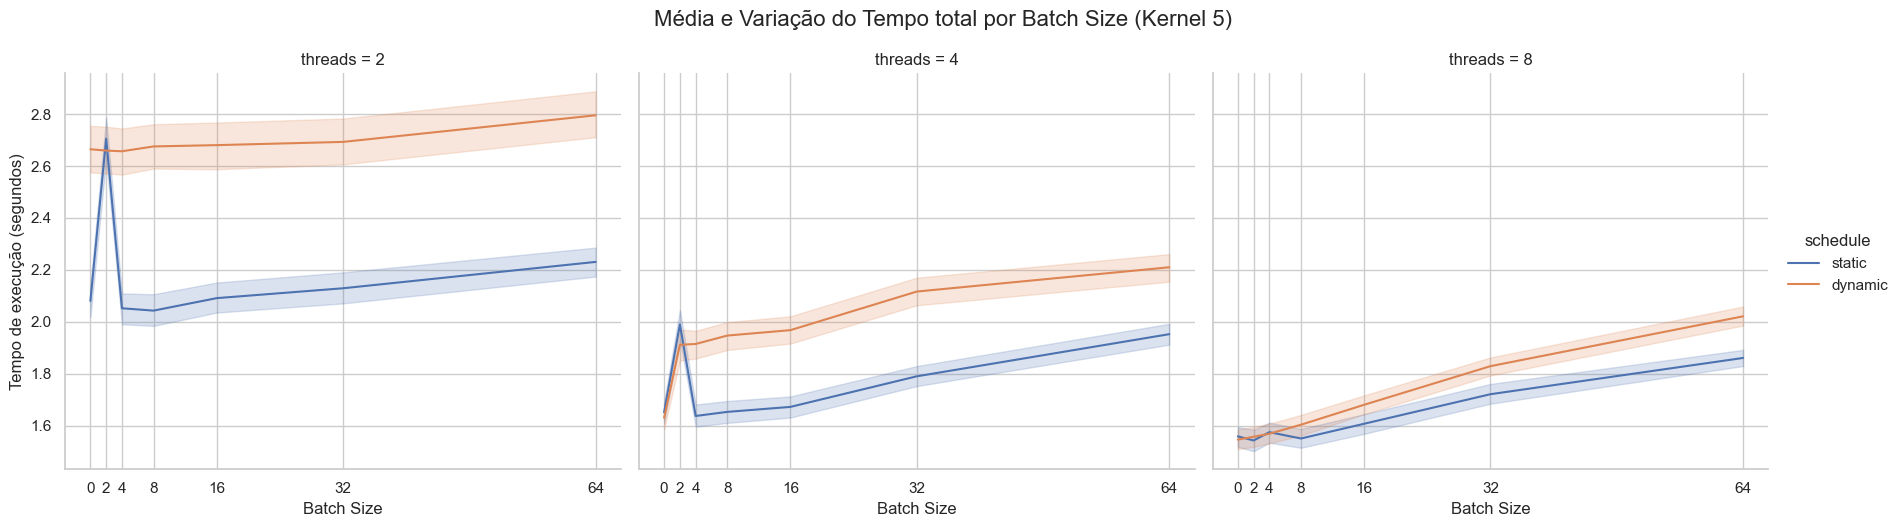

In [37]:
plot_schedule_batch_comparison(df_parallel[df_parallel['windows_size'] == '5'], kernel='5')

In [38]:
df_grouped_kernel_7 = group_data_by_schedule_and_batch(df_parallel[df_parallel['windows_size'] == '7'])
df_grouped_kernel_7.sort_values(by='median')

mean    median       std       min        max        CV
threads schedule                                                             
8       static    2.281139  2.057838  1.031204  0.807119   6.271149  0.452057
        dynamic   2.292656  2.123202  1.031296  0.815029   6.075231  0.449826
4       static    2.551302  2.215199  1.326292  0.850425   8.337440  0.519849
        dynamic   2.695934  2.245628  1.428898  0.867210   8.289590  0.530020
2       dynamic   3.746132  2.465988  2.379250  1.044541  12.576018  0.635122
        static    3.274659  2.542185  1.991283  1.051070  12.257641  0.608089

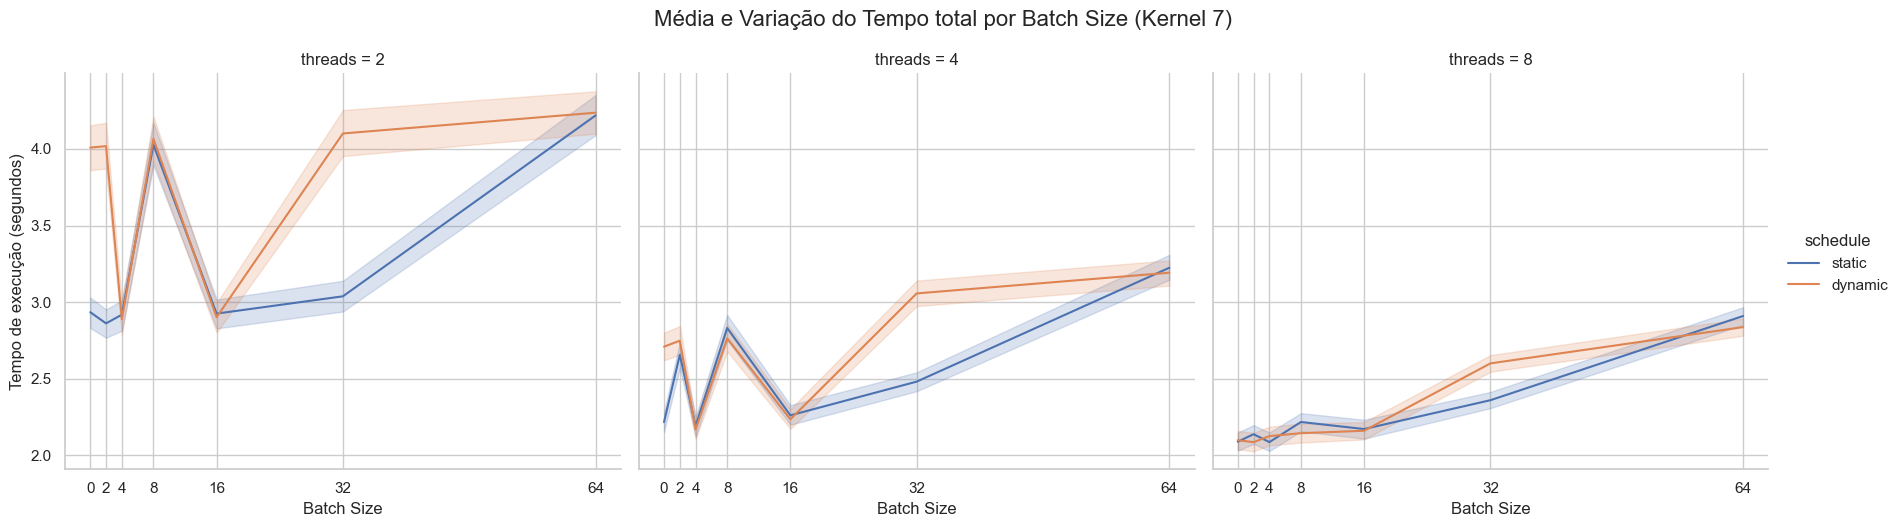

In [39]:
plot_schedule_batch_comparison(df_parallel[df_parallel['windows_size'] == '7'], kernel='7')

In [40]:
df_grouped_kernel_9 = group_data_by_schedule_and_batch(df_parallel[df_parallel['windows_size'] == '9'])
df_grouped_kernel_9.sort_values(by='median')

mean    median       std       min        max        CV
threads schedule                                                             
8       static    2.744068  2.566338  1.322238  0.938738   7.529508  0.481853
        dynamic   2.789169  2.630823  1.296461  0.946308   7.416165  0.464820
4       static    2.970449  2.686878  1.522604  1.006441   8.496034  0.512584
        dynamic   3.262144  2.742096  1.783081  0.999843  10.272354  0.546598
2       static    4.000481  3.195916  2.363233  1.313688  11.786032  0.590737
        dynamic   4.766495  3.425084  3.087357  1.273176  16.129393  0.647721

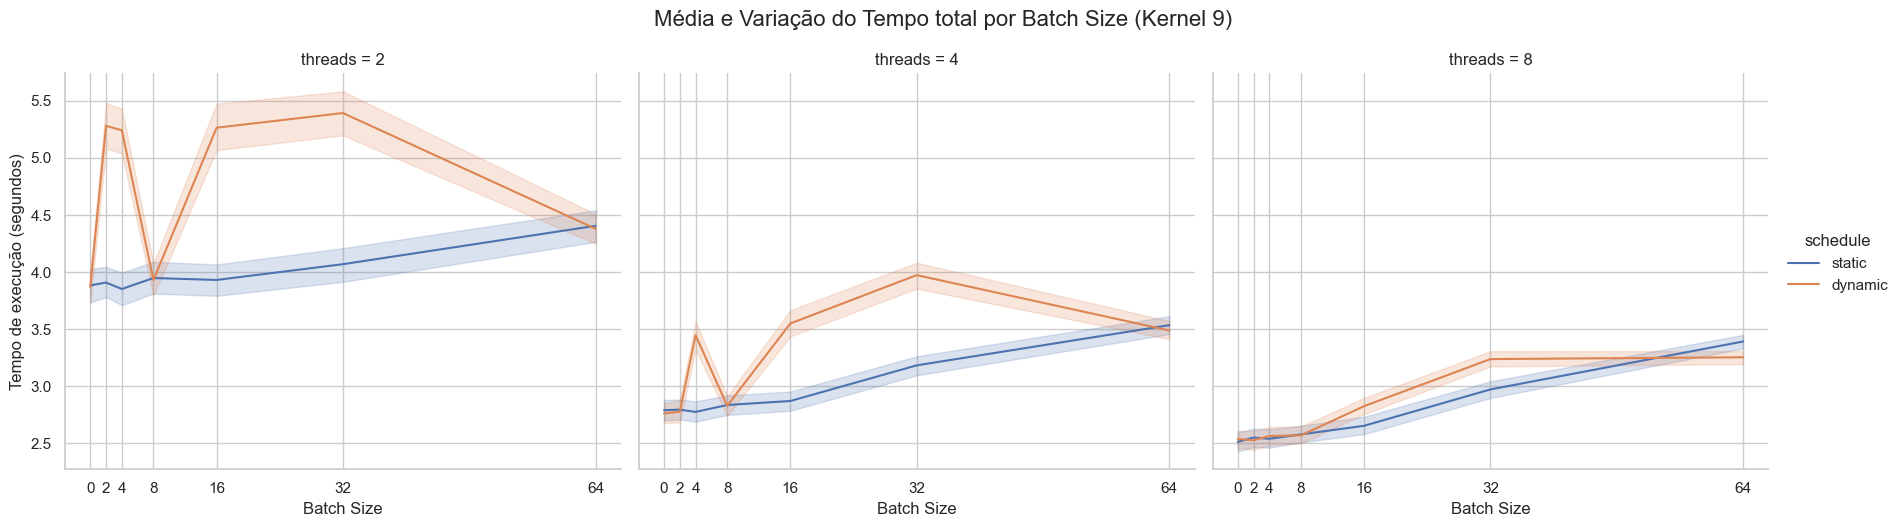

In [41]:
plot_schedule_batch_comparison(df_parallel[df_parallel['windows_size'] == '9'], kernel='9')

### 3.3 Teste de corretude paralela

A última validação dos dados se deu com os resultados paralelas contra as saidas da parte sequencial da implementação em C++. Como tratavam da exata mesma lógica, linguagem e gerência de dados do núcleo, o tolerável de falhas em ponto flutuante escolhido foi o limiar matemático rigoroso de 1e-25.

In [42]:
# verificação de IDs para garantir que filtrar os dados sequenciais 
# não resultou em perda de dados
unique_ids_parallel = df_parallel['id'].unique()
print(unique_ids_parallel)
print(f"Total de IDs únicos parelelos: {len(unique_ids)}")

if set(unique_ids_parallel) == set(unique_ids):
    print("Todos os IDs únicos do paralelo estão presentes no sequencial.")
else:
    print("Alerta: Nem todos os IDs únicos do paralelo estão presentes no sequencial. Verifique os dados de entrada.")


<StringArray>
['TRV1P1', 'TRV1P2', 'TRV1P3', 'TRV1P4', 'TRV1P5', 'TRV1P6', 'TRV1P7',
 'TRV1P8', 'TRV3P1', 'TRV3P2', 'TRV3P3', 'TRV3P4', 'TRV3P5', 'TRV3P6',
 'TRV3P7', 'TRV3P8', 'TRV4P1', 'TRV4P2', 'TRV4P3', 'TRV4P4', 'TRV4P5',
 'TRV4P6', 'TRV4P7', 'TRV4P8', 'TEV1P1', 'TEV1P2', 'TEV1P3', 'TEV1P4',
 'TEV1P5', 'TEV1P6', 'TEV1P7', 'TEV1P8', 'TEV3P1', 'TEV3P2', 'TEV3P3',
 'TEV3P4', 'TEV3P5', 'TEV3P6', 'TEV3P7', 'TEV3P8', 'TEV4P1', 'TEV4P2',
 'TEV4P3', 'TEV4P4', 'TEV4P5', 'TEV4P6', 'TEV4P7', 'TEV4P8', 'VAV1P1',
 'VAV1P2', 'VAV2P1', 'VAV2P2', 'VAV3P1', 'VAV3P2', 'VAV4P1', 'VAV4P2']
Length: 56, dtype: str
Total de IDs únicos parelelos: 56
Todos os IDs únicos do paralelo estão presentes no sequencial.


In [43]:
df_final = pd.concat([df_parallel, df_seq], ignore_index=True)
df_final.head()

,id,windows_size,cortes,tempo_leitura,tempo_medio_slice,tempo_busca,tempo_total,melhor_corte,ssim_maximo,batch_size,threads,schedule
0,TRV1P1,5,280,0.838853,0.014009,1.967668,2.806959,198,0.868385,0,2,static
1,TRV1P1,5,280,0.859593,0.015074,2.111243,2.971607,198,0.868385,0,2,static
2,TRV1P1,5,280,0.852741,0.014448,2.026188,2.879722,198,0.868385,0,2,static
3,TRV1P1,5,280,0.954891,0.015357,2.152525,3.108284,198,0.868385,0,2,static
4,TRV1P1,5,280,0.849628,0.014202,1.991892,2.842259,198,0.868385,0,2,static


In [44]:
df_final['threads'] = df_final['threads'].astype(float)
df_final['batch_size'] = df_final['batch_size'].astype(float)

In [45]:
print(f"Total de registros: {len(df_final)}")

Total de registros: 145440


As comparações cobriram as saídas geradas por todas as versões dos *kernels* empregados nas testagens paralelizadoras. O resultado não acusou sequer um único caso de incoerência em fatias eleitas ou da similaridade absoluta, consolidando que o laço assíncrono evitou condições de corrida com êxito.

In [46]:
result = teste_corretude(df_ref = df_final[(df_final['windows_size'] == '5') & (df_final['schedule'] == 'sequencial')],
                         df_comp = df_final[(df_final['windows_size'] == '5') & (df_final['schedule'] == 'static')], 
                         lista_ids = unique_ids,
                         nome_ref = 'Sequencial',
                         nome_comp = 'Static')
print(f"Total de comparações: {result['num_comp']}")
print(f"Diferenças encontradas nos melhores cortes: {result['num_index_diff']}")
print(f"Diferenças encontradas nos valores de SSIM: {result['num_ssim_diff']}")

ID VAV1P1 | Cortes 64
  - Resultados consistentes
ID VAV1P1 | Cortes 235
  - Resultados consistentes
ID VAV1P2 | Cortes 280
  - Resultados consistentes
ID VAV1P2 | Cortes 64
  - Resultados consistentes
ID TEV4P7 | Cortes 48
  - Resultados consistentes
ID TEV4P7 | Cortes 331
  - Resultados consistentes
ID TEV4P8 | Cortes 48
  - Resultados consistentes
ID TEV4P8 | Cortes 333
  - Resultados consistentes
Total de comparações: 112
Diferenças encontradas nos melhores cortes: 0
Diferenças encontradas nos valores de SSIM: 0


In [47]:
result = teste_corretude(df_ref = df_final[(df_final['windows_size'] == '7') & (df_final['schedule'] == 'sequencial')],
                         df_comp = df_final[(df_final['windows_size'] == '7') & (df_final['schedule'] == 'static')], 
                         lista_ids = unique_ids,
                         nome_ref = 'Sequencial',
                         nome_comp = 'Static')
print(f"Total de comparações: {result['num_comp']}")
print(f"Diferenças encontradas nos melhores cortes: {result['num_index_diff']}")
print(f"Diferenças encontradas nos valores de SSIM: {result['num_ssim_diff']}")

ID VAV1P1 | Cortes 64
  - Resultados consistentes
ID VAV1P1 | Cortes 235
  - Resultados consistentes
ID VAV1P2 | Cortes 280
  - Resultados consistentes
ID VAV1P2 | Cortes 64
  - Resultados consistentes
ID TEV4P7 | Cortes 48
  - Resultados consistentes
ID TEV4P7 | Cortes 331
  - Resultados consistentes
ID TEV4P8 | Cortes 48
  - Resultados consistentes
ID TEV4P8 | Cortes 333
  - Resultados consistentes
Total de comparações: 112
Diferenças encontradas nos melhores cortes: 0
Diferenças encontradas nos valores de SSIM: 0


In [48]:
result = teste_corretude(df_ref = df_final[(df_final['windows_size'] == '9') & (df_final['schedule'] == 'sequencial')],
                         df_comp = df_final[(df_final['windows_size'] == '9') & (df_final['schedule'] == 'static')], 
                         lista_ids = unique_ids,
                         nome_ref = 'Sequencial',
                         nome_comp = 'Static')
print(f"Total de comparações: {result['num_comp']}")
print(f"Diferenças encontradas nos melhores cortes: {result['num_index_diff']}")
print(f"Diferenças encontradas nos valores de SSIM: {result['num_ssim_diff']}")

ID VAV1P1 | Cortes 64
  - Resultados consistentes
ID VAV1P1 | Cortes 235
  - Resultados consistentes
ID VAV1P2 | Cortes 280
  - Resultados consistentes
ID VAV1P2 | Cortes 64
  - Resultados consistentes
ID TEV4P7 | Cortes 48
  - Resultados consistentes
ID TEV4P7 | Cortes 331
  - Resultados consistentes
ID TEV4P8 | Cortes 48
  - Resultados consistentes
ID TEV4P8 | Cortes 333
  - Resultados consistentes
Total de comparações: 112
Diferenças encontradas nos melhores cortes: 0
Diferenças encontradas nos valores de SSIM: 0


In [49]:
result = teste_corretude(df_ref = df_final[(df_final['windows_size'] == '5') & (df_final['schedule'] == 'sequencial')],
                         df_comp = df_final[(df_final['windows_size'] == '5') & (df_final['schedule'] == 'dynamic')], 
                         lista_ids = unique_ids,
                         nome_ref = 'Sequencial',
                         nome_comp = 'Dynamic')
print(f"Total de comparações: {result['num_comp']}")
print(f"Diferenças encontradas nos melhores cortes: {result['num_index_diff']}")
print(f"Diferenças encontradas nos valores de SSIM: {result['num_ssim_diff']}")

ID VAV1P1 | Cortes 64
  - Resultados consistentes
ID VAV1P1 | Cortes 235
  - Resultados consistentes
ID VAV1P2 | Cortes 280
  - Resultados consistentes
ID VAV1P2 | Cortes 64
  - Resultados consistentes
ID TEV4P7 | Cortes 48
  - Resultados consistentes
ID TEV4P7 | Cortes 331
  - Resultados consistentes
ID TEV4P8 | Cortes 48
  - Resultados consistentes
ID TEV4P8 | Cortes 333
  - Resultados consistentes
Total de comparações: 112
Diferenças encontradas nos melhores cortes: 0
Diferenças encontradas nos valores de SSIM: 0


In [50]:
result = teste_corretude(df_ref = df_final[(df_final['windows_size'] == '7') & (df_final['schedule'] == 'sequencial')],
                         df_comp = df_final[(df_final['windows_size'] == '7') & (df_final['schedule'] == 'dynamic')], 
                         lista_ids = unique_ids,
                         nome_ref = 'Sequencial',
                         nome_comp = 'Dynamic')
print(f"Total de comparações: {result['num_comp']}")
print(f"Diferenças encontradas nos melhores cortes: {result['num_index_diff']}")
print(f"Diferenças encontradas nos valores de SSIM: {result['num_ssim_diff']}")

ID VAV1P1 | Cortes 64
  - Resultados consistentes
ID VAV1P1 | Cortes 235
  - Resultados consistentes
ID VAV1P2 | Cortes 280
  - Resultados consistentes
ID VAV1P2 | Cortes 64
  - Resultados consistentes
ID TEV4P7 | Cortes 48
  - Resultados consistentes
ID TEV4P7 | Cortes 331
  - Resultados consistentes
ID TEV4P8 | Cortes 48
  - Resultados consistentes
ID TEV4P8 | Cortes 333
  - Resultados consistentes
Total de comparações: 112
Diferenças encontradas nos melhores cortes: 0
Diferenças encontradas nos valores de SSIM: 0


In [51]:
result = teste_corretude(df_ref = df_final[(df_final['windows_size'] == '9') & (df_final['schedule'] == 'sequencial')],
                         df_comp = df_final[(df_final['windows_size'] == '9') & (df_final['schedule'] == 'dynamic')], 
                         lista_ids = unique_ids,
                         nome_ref = 'Sequencial',
                         nome_comp = 'Dynamic')
print(f"Total de comparações: {result['num_comp']}")
print(f"Diferenças encontradas nos melhores cortes: {result['num_index_diff']}")
print(f"Diferenças encontradas nos valores de SSIM: {result['num_ssim_diff']}")

ID VAV1P1 | Cortes 64
  - Resultados consistentes
ID VAV1P1 | Cortes 235
  - Resultados consistentes
ID VAV1P2 | Cortes 280
  - Resultados consistentes
ID VAV1P2 | Cortes 64
  - Resultados consistentes
ID TEV4P7 | Cortes 48
  - Resultados consistentes
ID TEV4P7 | Cortes 331
  - Resultados consistentes
ID TEV4P8 | Cortes 48
  - Resultados consistentes
ID TEV4P8 | Cortes 333
  - Resultados consistentes
Total de comparações: 112
Diferenças encontradas nos melhores cortes: 0
Diferenças encontradas nos valores de SSIM: 0


### 3.4 Teste de desempenho paralela

Na averiguação em profundidade, extraiu-se o impacto quantitativa de núcleos, *batch_size* e o volume imposto pelo *kernel* aos processadores.

In [52]:
colunas_agrupamento = ['id', 'cortes', 'batch_size', 'threads', 'schedule', 'windows_size']
colunas_tempo = ['tempo_leitura', 'tempo_medio_slice', 'tempo_busca', 'tempo_total']

df_medio = df_final.groupby(colunas_agrupamento, dropna=False)[colunas_tempo].mean().reset_index()
df_medio.head()

,id,cortes,batch_size,threads,schedule,windows_size,tempo_leitura,tempo_medio_slice,tempo_busca,tempo_total
0,TEV1P1,64,0.0,2.0,dynamic,5,0.632659,0.020767,0.666034,1.299246
1,TEV1P1,64,0.0,2.0,dynamic,7,0.697645,0.036240,1.162452,1.860776
2,TEV1P1,64,0.0,2.0,dynamic,9,0.689826,0.036722,1.177371,1.867769
3,TEV1P1,64,0.0,2.0,static,5,0.678700,0.013872,0.445309,1.124562
4,TEV1P1,64,0.0,2.0,static,7,0.704395,0.024739,0.794106,1.499076


Para avaliação de desempenho foram cálculadas os seguintes indicadores de paralelismo: 
- A Aceleração (*Speedup*), definida como a divisão algébrica do tempo de execução sequencial pelo tempo de execução paralelo, ou seja, quanto maior o *speedup*, mais rápido o programa ficou com a paralelização, sendo o ideal o *speedup* ser igual ao número de *threads* utilizadas.
- E a Eficiência, que quantificava o aproveitamento desse ganho frente a capacidade computacional disponivel, e é calculada pelo *Speedup* dividido pelo quantidade de *threads* utilizadas, ou seja, quanto mais próximo de 1, mais eficiente é a paralelização do programa, já que o ideal seria o *speedup* ser igual ao número de *threads* utilizadas. Dada a limitação em 4 *cores* nativos da CPU submetida, o cálculo de aproveitamento restringiu-se ao divisor 4, mesmo para os casos de 8 *threads*, visto que o ganho de desempenho não pode ser superior ao número de núcleos físicos disponíveis.

In [53]:
# separacao de dados sequenciais
df_seq = df_medio[df_medio['schedule'] == 'sequencial'].copy()
df_seq = df_seq[['id', 'tempo_total', 'windows_size', 'cortes']].rename(columns={'tempo_total': 'tempo_total_seq'})

# separacao de dados paralelos
df_par = df_medio[df_medio['schedule'] != 'sequencial'].copy()

# juncao dos dados sequenciais e paralelos para analise de speedup e eficiencia
df_analise = df_par.merge(df_seq, on=['id', 'windows_size', 'cortes'], how='inner')

# calculo de speedup e eficiencia
df_analise['speedup_total'] = df_analise['tempo_total_seq'] / df_analise['tempo_total']
df_analise['eficiencia'] = df_analise['speedup_total'] / df_analise['threads']
df_analise.loc[df_analise['threads'] > NUCLEOS_FISICOS, 'eficiencia'] = df_analise[df_analise['threads'] > NUCLEOS_FISICOS]['speedup_total'] / NUCLEOS_FISICOS

In [54]:
df_analise[['id', 'cortes', 'threads', 'batch_size', 'tempo_total_seq', 'tempo_total', 'speedup_total', 'eficiencia']].head()

,id,cortes,threads,batch_size,tempo_total_seq,tempo_total,speedup_total,eficiencia
0,TEV1P1,64,2.0,0.0,1.435277,1.299246,1.104700,0.552350
1,TEV1P1,64,2.0,0.0,2.037855,1.860776,1.095164,0.547582
2,TEV1P1,64,2.0,0.0,2.630359,1.867769,1.408289,0.704145
3,TEV1P1,64,2.0,0.0,1.435277,1.124562,1.276299,0.638149
4,TEV1P1,64,2.0,0.0,2.037855,1.499076,1.359407,0.679704


Os indicativos agregados por *threads* e *kernels* ditaram que o foi obtido maior desempenho em *kernels* geometricamente maiores (ex: 9x9), ambientes onde matrizes de maior dimensão propiciaram uma uso vantajos da abordagem paralela. O limite de processamento atingido foi de 1,97x, atrelado ao teste em 8 *threads* com *kernel* 9.

Em termos de eficiência, o dimensionamento de 2 *threads* demonstrou o pico de produtividade com 60% de média aproximada (com pico de mais de 65% segmentando por *kernel*). Em contraponto, as divisões com 4 *threads* estagnaram em valores baixos, girando em torno dos 40%.

In [55]:
resumo_by_kernel = df_analise.groupby(['threads', 'windows_size']).agg(
    tempo_total_medio=('tempo_total', 'mean'),
    tempo_total_medio_seq=('tempo_total_seq', 'mean'),
    speedup_medio=('speedup_total', 'mean'),
    eficiencia_media=('eficiencia', 'mean')
).reset_index()

resumo_by_kernel['speedup_medio'] = resumo_by_kernel['speedup_medio'].round(4)
resumo_by_kernel['tempo_total_medio'] = resumo_by_kernel['tempo_total_medio'].round(4)
resumo_by_kernel['tempo_total_medio_seq'] = resumo_by_kernel['tempo_total_medio_seq'].round(4)
resumo_by_kernel['eficiencia_media'] = resumo_by_kernel['eficiencia_media'].round(4)


resumo_by_kernel.sort_values(by=['threads', 'windows_size'])

,threads,windows_size,tempo_total_medio,tempo_total_medio_seq,speedup_medio,eficiencia_media
0,2.0,5,2.4398,2.8519,1.1551,0.5775
1,2.0,7,3.5104,4.2865,1.2179,0.6089
2,2.0,9,4.3835,5.9341,1.3153,0.6577
3,4.0,5,1.8606,2.8519,1.4600,0.3650
4,4.0,7,2.6236,4.2865,1.5526,0.3881
5,4.0,9,3.1163,5.9341,1.7779,0.4445
6,8.0,5,1.6592,2.8519,1.6194,0.4048
7,8.0,7,2.2869,4.2865,1.7458,0.4364
8,8.0,9,2.7666,5.9341,1.9755,0.4939


In [56]:
def plot_batch_comparison(df: pd.DataFrame, kernel: str = None, schedule_type: str = None) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    title = f'Resultados de Speedup e Eficiência'
    if kernel:
        title += f' - Kernel {kernel}'
    fig.suptitle(title, fontsize=16)
    
    sns.lineplot(
        data=df, 
        x='batch_size', 
        y='speedup_total', 
        hue='threads',
        marker='o',
        palette='Set1',
        ax=axes[0],
    )
    
    x_label = f'Batch Size (schedule {schedule_type})' if schedule_type else 'Batch Size'
    
    axes[0].set_title('Speedup vs Batch Size', fontsize=14)
    axes[0].set_xlabel(f'{x_label}', fontsize=12)
    axes[0].set_ylabel('Speedup (Vezes mais rápido)', fontsize=12)
    axes[0].axhline(1, ls='--', color='gray', label='Speedup 1 (Sequencial)')
    axes[0].legend(title='Threads')

    sns.lineplot(
        data=df, 
        x='batch_size',
        y='eficiencia',
        hue='threads',
        palette='Set1',
        marker='s',
        ax=axes[1],
    )
    axes[1].set_title('Eficiência vs Batch Size', fontsize=14)
    axes[1].set_xlabel(f'{x_label}', fontsize=12)
    axes[1].set_ylabel('Eficiência (0 a 1)', fontsize=12)
    axes[1].axhline(1, ls='--', color='green', label='Eficiência 100%')
    axes[1].axhline(0.5, ls='--', color='gray', alpha=0.5)
    axes[1].legend(title='Threads')

    plt.tight_layout()
    plt.show()

Adiante gráficas plotadas consolidaram uma correlação inversa de tempo gasta com o valor de `batch_size`. Em via de regra, inflar lotes predefinidos estressou demasiadamente as partes paralelas, gerando um maior tempo de execução uma vez que algumas *threads* ficavam ociosas enquanto outras processavam lotes maiores.
De maneira geral, a omissão do lote para delegação de divisão de carga do OpenMP, mostrou-se como conduta com melhores ganhos, ou muito proximo disso. A apenas a exceção notavel do cenario com kernel 7 em que o `batch_size` 0 teve resultados piores que o `batch_size` 4 e 16.

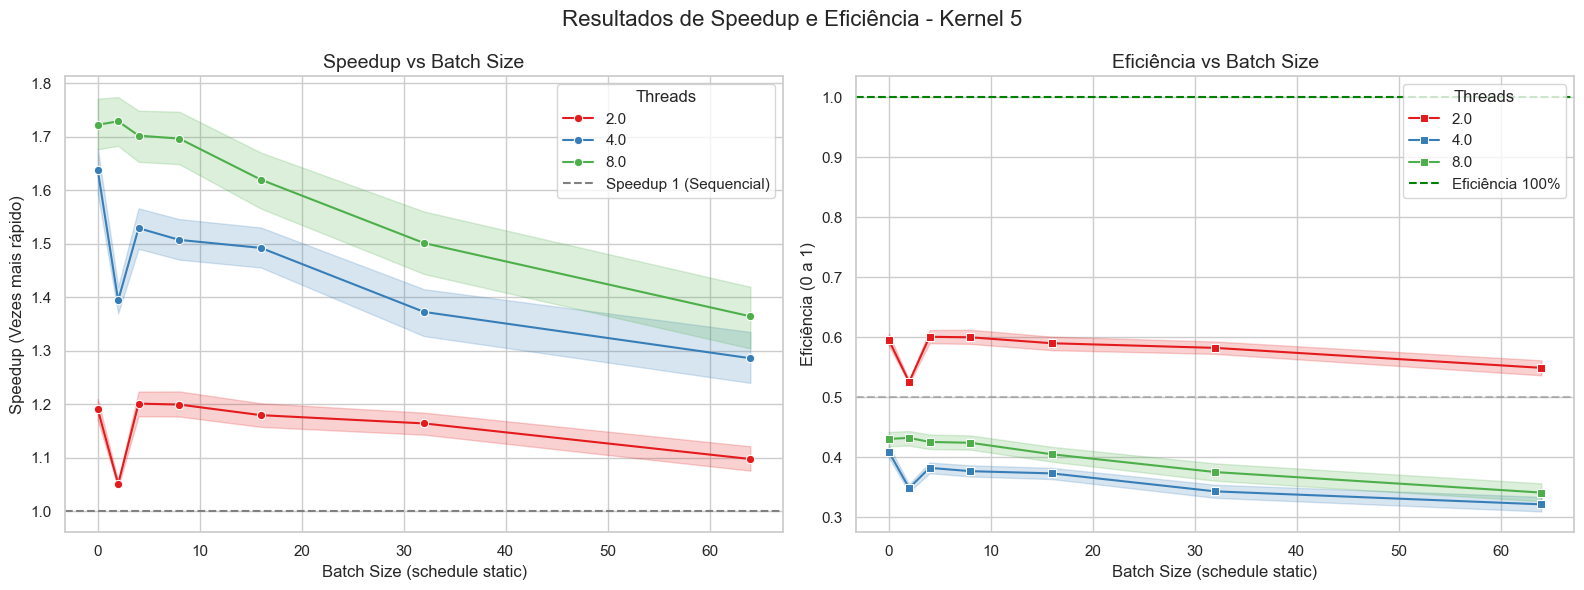

In [57]:
plot_batch_comparison(df_analise[df_analise['windows_size'] == '5'], kernel='5', schedule_type='static')

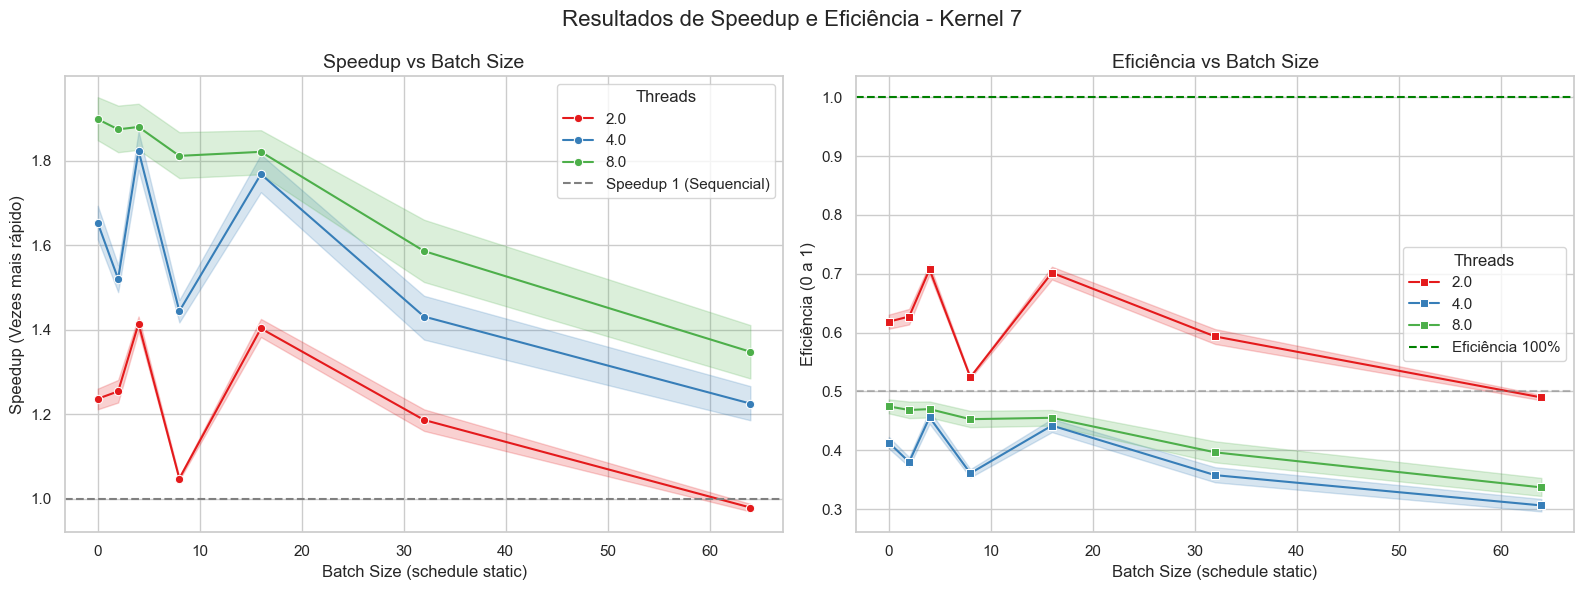

In [58]:
plot_batch_comparison(df_analise[df_analise['windows_size'] == '7'], kernel='7', schedule_type='static')

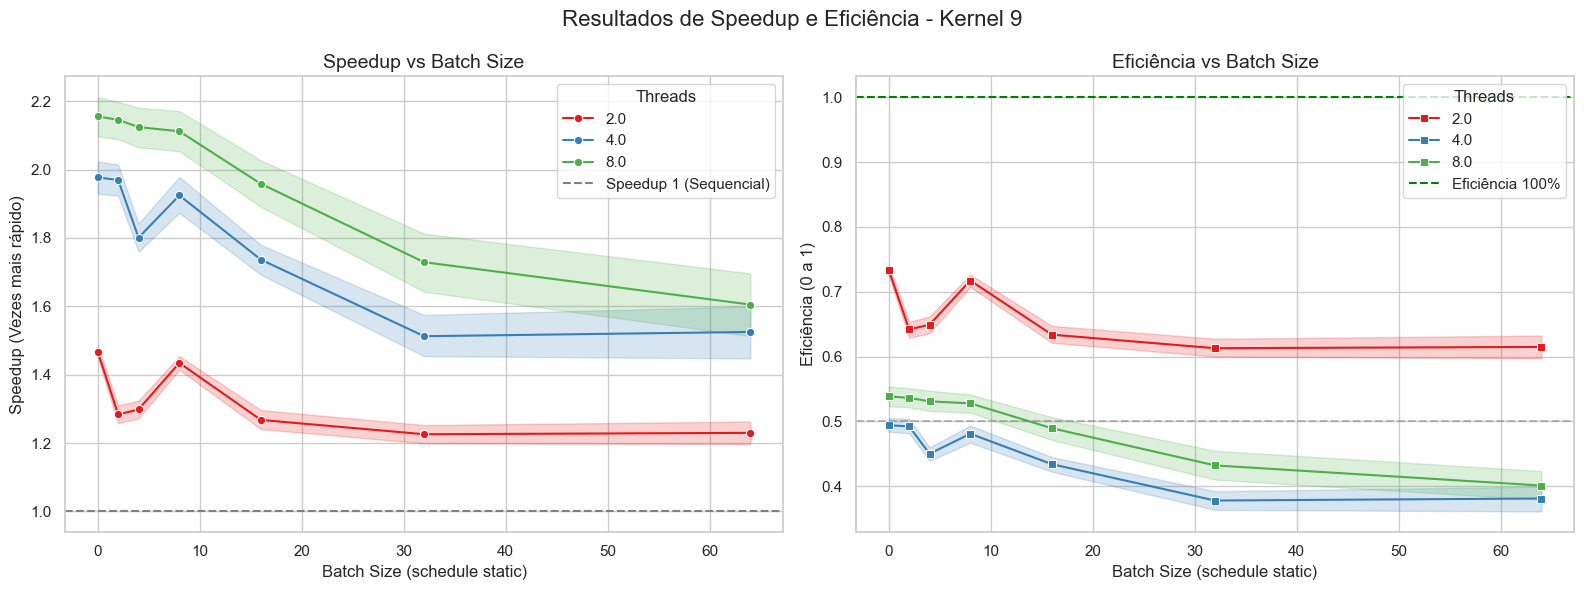

In [59]:
plot_batch_comparison(df_analise[df_analise['windows_size'] == '9'], kernel='9', schedule_type='static')

In [60]:
tabela_resumo = df_analise.groupby(['threads', 'batch_size', 'windows_size']).agg(
    tempo_total_medio=('tempo_total', 'mean'),
    tempo_total_medio_seq=('tempo_total_seq', 'mean'),
    speedup_medio=('speedup_total', 'mean'),
    eficiencia_media=('eficiencia', 'mean')
).reset_index()

tabela_resumo['speedup_medio'] = tabela_resumo['speedup_medio'].round(4)
tabela_resumo['tempo_total_medio'] = tabela_resumo['tempo_total_medio'].round(4)
tabela_resumo['tempo_total_medio_seq'] = tabela_resumo['tempo_total_medio_seq'].round(4)
tabela_resumo['eficiencia_media'] = tabela_resumo['eficiencia_media'].round(4)

Em um recorte do cenário ótimo (`batch_size` zerado), verificou-se um *Speedup* real de 2,15 vezes em 8 instâncias (*kernel* 9), o que representa um ganho de desempenho significativo em relação à média geral de 1,97 vezes. Além de uma eficiência superior a 73% obtida com 2 *threads* para o mesmo *kernel*. No geral, apesar de em alguns casos a escolha do `batch_size` ter gerado uma melhora não muito significativa, a tendência geral indicou que essa configuração de divisão de carga foi beneficial para o desempenho do programa no conjunto de dados testado.


In [61]:
tabela_resumo[tabela_resumo['batch_size'] == 0].sort_values(by=['threads', 'windows_size'])

,threads,batch_size,windows_size,tempo_total_medio,tempo_total_medio_seq,speedup_medio,eficiencia_media
0,2.0,0.0,5,2.3726,2.8519,1.1909,0.5955
1,2.0,0.0,7,3.4716,4.2865,1.2371,0.6186
2,2.0,0.0,9,3.8780,5.9341,1.4674,0.7337
21,4.0,0.0,5,1.6412,2.8519,1.6376,0.4094
22,4.0,0.0,7,2.4627,4.2865,1.6529,0.4132
23,4.0,0.0,9,2.7777,5.9341,1.9768,0.4942
42,8.0,0.0,5,1.5530,2.8519,1.7223,0.4306
43,8.0,0.0,7,2.0932,4.2865,1.8984,0.4746
44,8.0,0.0,9,2.5267,5.9341,2.1551,0.5388


Como exceção a melhora geral para a omissão do `batch_size`, para o *kernel* 7 os resultados com `batch_size` 4 gerou resultados melhores. Essa janela conseguiu melhorar quase 9% a mais de produtividade frente para a execução com duas threads e cerca de 4% para a execução com 4 threads, e uma melhora menos expressiva de 0.5% para o kernel 7 com 8 threads, o que indica que o `batch_size` 4 pode ser uma boa escolha para o kernel 7, principalmente para o caso de 2 threads.


In [62]:
tabela_resumo[tabela_resumo['batch_size'] == 4].sort_values(by=['threads', 'windows_size'])

,threads,batch_size,windows_size,tempo_total_medio,tempo_total_medio_seq,speedup_medio,eficiencia_media
6,2.0,4.0,5,2.3546,2.8519,1.2015,0.6007
7,2.0,4.0,7,2.9035,4.2865,1.4148,0.7074
8,2.0,4.0,9,4.5479,5.9341,1.2982,0.6491
27,4.0,4.0,5,1.7763,2.8519,1.5293,0.3823
28,4.0,4.0,7,2.1794,4.2865,1.8243,0.4561
29,4.0,4.0,9,3.1123,5.9341,1.8008,0.4502
48,8.0,4.0,5,1.5724,2.8519,1.7022,0.4255
49,8.0,4.0,7,2.1053,4.2865,1.8801,0.4700
50,8.0,4.0,9,2.5533,5.9341,2.1241,0.5310


## 4. Conclussão

Este relatório validou a implementação sequencial e paralela de um sistema computacional focado no cálculo da similaridade estrutural (SSIM) entre tomografias computadorizadas. Os testes de corretude confirmaram que tanto a tradução do algoritmo original em Python para C++, quanto a paralelização utilizando a biblioteca OpenMP, preservaram a exatidão matemática dos resultados.

Na análise das estratégias de escalonamento (scheduling), o método estático (static) apresentou um desempenho consistentemente superior ao dinâmico (dynamic). A implementação paralela conseguiu reduzir significativamente o tempo de execução do laço principal, alcançando uma aceleração (Speedup) máxima de 2,15 vezes em relação ao código sequencial.

Em relação ao uso de recursos e à distribuição das tarefas, a análise constatou que a maior eficiência (atingindo até 73%) ocorreu com a utilização de apenas 2 threads. Além disso, os testes demonstraram que a melhor abordagem geral para o conjunto de dados foi deixar o tamanho do lote automático (omitindo o parâmetro batch_size). A única exceção ocorreu no processamento com o kernel 7, onde a definição de um batch_size fixo, variando entre 4 e 16 fatias, entregou um desempenho superior. Em suma, o uso do processamento paralelo viabilizou com êxito a aceleração necessária para lidar com o alto custo computacional da análise dessas imagens tridimensionais.